In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

#Data Loading
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Visualisation of top 5 jobs & job schedules

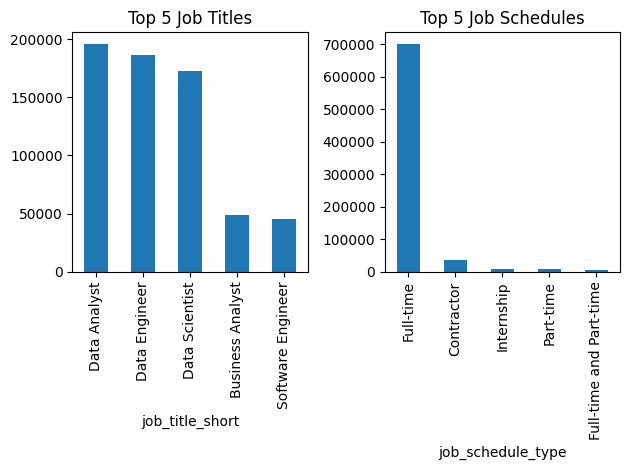

In [35]:
fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().head().plot(kind='bar', title='Top 5 Job Titles', ax=ax[0])
df['job_schedule_type'].value_counts().head().plot(kind='bar', title='Top 5 Job Schedules', ax=ax[1])

fig.tight_layout()



**3 axes in 1 fig**

In [ ]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')

skills_count    = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
1054,mattermost,Data Scientist,1
270,clickup,Machine Learning Engineer,1
797,heroku,Senior Data Analyst,1


In [58]:
job_titles = ['Data Scientist','Data Engineer','Data Engineer']

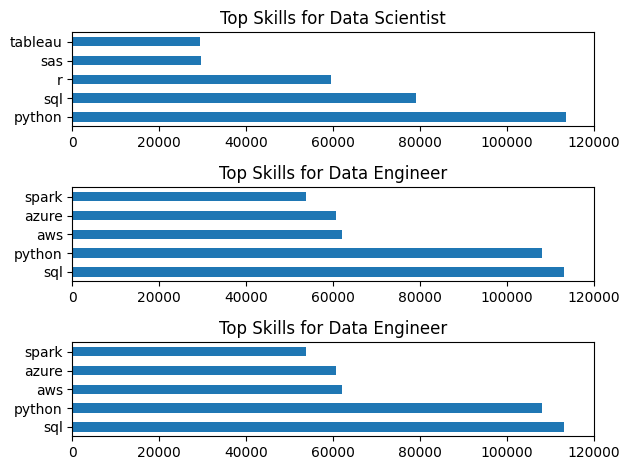

In [69]:
fig, ax = plt.subplots(3, 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=f'Top Skills for {job_title}')

    ax[i].legend().set_visible(False)
    ax[i].set_ylabel('')
    ax[i].set_xlim(0, 120000)

fig.tight_layout()